# Publication figure revision: five main figures and eight supplementary figures

Run all cells from the extracted package directory. This notebook contains the actual plotting functions, so each panel can be edited here. It uses only the supplied archived CSVs, performs no network requests and makes no optimisation or QPU calls.

Figures 2–5 and S1–S8 are regenerated as vector PDF, editable SVG and 600 dpi PNG. Figure 1 is the approved brighter graphical abstract, retained as an input asset; its editable PowerPoint is in `editable/`. The companion `plot_figures.py` provides the same baseline implementation as a command-line alternative. Changes made here are not automatically copied back to that script.

See `figure_strategy.md` for the complete migration map. Data provenance and exact derived panel tables are in `data/`, `source_data/` and `verification/`. No error bars or sensitivity curves are invented.

In [77]:
"""Publication figures from archived data only; no optimisation or network calls.

Run: python plot_figures.py
Each function writes a vector PDF, editable SVG and 600 dpi PNG. Figure 1 is the
previously approved graphical abstract and is retained as an existing asset.
"""
from pathlib import Path
import hashlib
import io
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import dates as mdates, colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ROOT = Path.cwd()
assert (ROOT/'data').is_dir(), 'Run this notebook from the extracted figure_revision_package folder.'
DATA, OUT, SOURCE = ROOT/'data', ROOT/'figures', ROOT/'source_data'
for directory in (OUT, SOURCE):
    directory.mkdir(exist_ok=True)
INK, MUTED, TEAL, ORANGE = '#102B42', '#3D5060', '#008C80', '#DA6000'
GRID, GREY, PALE = '#E4EBF0', '#748493', '#FFE0AE'
CAP = {250:'#00A58E', 300:'#009DDE', 350:'#3361D5', 400:'#7542C8'}
METHODS = ['D-Wave hybrid', 'CPLEX-QUBO', 'CPLEX-constrained', 'SA']
MC = dict(zip(METHODS, [TEAL, '#3361D5', '#7542C8', GREY]))
MARKERS = ['o', 's', '^']
MM = 1/25.4
plt.rcParams.update({
    'font.family':'sans-serif', 'font.sans-serif':['Liberation Sans','DejaVu Sans'],
    'font.size':7.8, 'axes.labelsize':7.8, 'axes.titlesize':8.4,
    'xtick.labelsize':7.2, 'ytick.labelsize':7.2, 'legend.fontsize':7.2,
    'text.color':INK, 'axes.labelcolor':INK, 'axes.edgecolor':MUTED,
    'xtick.color':MUTED, 'ytick.color':MUTED, 'axes.linewidth':0.85,
    'xtick.major.width':0.8, 'ytick.major.width':0.8,
    'xtick.major.size':3.2, 'ytick.major.size':3.2,
    'axes.spines.top':False, 'axes.spines.right':False,
    'pdf.fonttype':42, 'ps.fonttype':42, 'svg.fonttype':'none',
    'savefig.facecolor':'white', 'figure.facecolor':'white',
    'hatch.linewidth':0.55, 'axes.unicode_minus':True,
})

SUMMARY = pd.read_csv(DATA/'dwave_hybrid_summary.csv').sort_values('event_id').reset_index(drop=True)
PROFILES = pd.read_csv(DATA/'event_profiles_long.csv')
EVENTS = pd.read_csv(DATA/'selected_caiso_events.csv').sort_values('event_id')
JOBS = pd.read_csv(DATA/'benchmark_spot_jobs_dvfs.csv').sort_values('portfolio_job_id')
CAL = pd.read_csv(DATA/'emerald_dvfs_calibration.csv').sort_values('power_cap_W')
SWEEP = pd.read_csv(DATA/'dvfs_sweep.csv')
BASE = pd.read_csv(DATA/'revised_solver_benchmark.csv')
BASE_TRACES = pd.read_csv(DATA/'revised_solver_trajectories.csv')
TRACES = {i:pd.read_csv(DATA/f'dwave_events/event_{i:02d}_trajectory.csv').sort_values('slot') for i in range(20)}
CHOSEN = {i:pd.read_csv(DATA/f'dwave_events/event_{i:02d}_chosen_variables.csv') for i in range(20)}
T = np.arange(24)*0.25
EDGES = np.arange(25)*0.25
P0 = float(PROFILES.flexible_envelope_peak_kW.iloc[0])

def panel(ax, letter, title):
    ax.set_title(title, loc='left', pad=8, fontweight='bold')
    ax.annotate(letter, (0,1.035), xycoords='axes fraction',
                xytext=(-18,0), textcoords='offset points',
                fontsize=11, fontweight='bold', va='bottom', clip_on=False)

def clean(ax, grid='y'):
    ax.set_axisbelow(True)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.6)

def step(ax, values, **kwargs):
    """Plot all 24 constant intervals, including the final interval to 6 h."""
    return ax.stairs(np.asarray(values), EDGES, baseline=None, **kwargs)

def source(name, df):
    df.to_csv(SOURCE/(name+'.csv'), index=False, float_format='%.12g')

def save(fig, name):
    for ext in ('pdf','svg','png'):
        buf=io.BytesIO()
        fig.savefig(buf, format=ext, dpi=600)
        (OUT/f'{name}.{ext}').write_bytes(buf.getvalue())
    plt.close(fig)
    return OUT/f'{name}.pdf'

def cap_legend(fig, y=0.99):
    fig.legend([Patch(facecolor=c, edgecolor=c) for c in CAP.values()],
               [f'{c} W cap' for c in CAP], ncol=4, frameon=False,
               loc='upper center', bbox_to_anchor=(.54,y), columnspacing=2)

def comparison():
    b = BASE[['event_id','method','tracking_RMSE_kW','tracking_objective','wall_time_s']].copy()
    h = SUMMARY.loc[SUMMARY.event_id<3,['event_id','tracking_RMSE_kW','tracking_objective','client_wall_time_s']].copy()
    h = h.rename(columns={'client_wall_time_s':'wall_time_s'})
    h['method']='D-Wave hybrid'
    return pd.concat([h,b], ignore_index=True)

def derived_metrics():
    rows=[]
    for e, d in TRACES.items():
        load=d.dwave_gpu_load_kW.to_numpy(); target=d.dispatch_target_kW.to_numpy()
        envelope=d.allocated_curtailment_kW.to_numpy(); ch=CHOSEN[e]
        rows.append(dict(event_id=e, rmse_kW=np.sqrt(np.mean((load-target)**2)),
            mean_target_kW=target.mean(), normalized_rmse_pct=100*np.sqrt(np.mean((load-target)**2))/target.mean(),
            target_kWh=target.sum()*.25, scheduled_kWh=load.sum()*.25,
            energy_mismatch_pct=100*(load.sum()/target.sum()-1),
            useful_gpu_h=(ch.total_gpus*ch.baseline_duration_minutes/60).sum(),
            max_exceedance_W=np.maximum(load-envelope,0).max()*1000,
            exceedance_Wh=np.maximum(load-envelope,0).sum()*.25*1000,
            jobs=len(ch), peak_gpus=d.dwave_active_gpus.max()))
    return pd.DataFrame(rows)

METRICS=derived_metrics()

def validate():
    """Independent arithmetic audit of all values used in the new figures."""
    checks={}
    for a,b in [('rmse_kW','tracking_RMSE_kW'),('target_kWh','target_energy_kWh'),
                ('scheduled_kWh','scheduled_gpu_energy_kWh'),('useful_gpu_h','completed_baseline_gpu_hours'),
                ('jobs','n_jobs_scheduled'),('peak_gpus','max_concurrent_gpus')]:
        err=float(np.max(np.abs(METRICS[a]-SUMMARY[b])))
        assert err<1e-8,(a,err)
        checks[a+'_max_abs_error']=err
    assert sum(len(x) for x in TRACES.values())==480
    for e,d in TRACES.items():
        ch=CHOSEN[e]; assert ch.portfolio_job_id.is_unique
        p=np.zeros(24); g=np.zeros(24)
        for _,v in ch.iterrows():
            p[int(v.start_slot):int(v.end_slot_exclusive)]+=v.job_power_kW
            g[int(v.start_slot):int(v.end_slot_exclusive)]+=v.total_gpus
        np.testing.assert_allclose(p,d.dwave_gpu_load_kW,atol=1e-10)
        np.testing.assert_allclose(g,d.dwave_active_gpus,atol=1e-10)
    for _,r in comparison().iterrows():
        assert abs(r.tracking_objective-24*(r.tracking_RMSE_kW/P0)**2)<1e-9
    for _,r in CAL.iterrows():
        sw=SWEEP[SWEEP['GPU power cap']==r.power_cap_W]
        np.testing.assert_allclose(sw['power per GPU'].mean(),r.power_per_gpu_W_mean)
        np.testing.assert_allclose(sw['normalized throughput'].min(),r.model_throughput_factor)
    checks.update(events=20,intervals=480,admitted_job_instances=sum(map(len,CHOSEN.values())),
                  unique_jobs=18,all_loads_reconstructed=True,all_baseline_objective_identities_verified=True,
                  source_data_only=True,no_new_solver_calls=True)
    (ROOT/'verification').mkdir(exist_ok=True)
    (ROOT/'verification/data_validation.json').write_text(json.dumps(checks,indent=2))
    source('event_metrics_recomputed',METRICS)
    source('solver_comparison',comparison())
    return checks


def work_by_cap():
    rows=[]
    for e,ch in CHOSEN.items():
        for cap in CAP:
            z=ch[ch.power_cap_W==cap]
            rows.append(dict(event_id=e,power_cap_W=cap,jobs=len(z),
                useful_gpu_h=(z.total_gpus*z.baseline_duration_minutes/60).sum(),
                scheduled_gpu_h=(z.total_gpus*z.duration_slots*.25).sum(),
                energy_kWh=(z.job_power_kW*z.duration_slots*.25).sum()))
    return pd.DataFrame(rows)
from IPython.display import SVG, Image, display


## New figures output folder
The previous run's outputs were moved to `figures_old/`. This creates a fresh `figures/` folder for the current figure set.

In [78]:
OUT.mkdir(parents=True, exist_ok=True)
print(f'Saving new figures to: {OUT}')

Saving new figures to: /Users/kumarghosh/Desktop/other_projects_till_Jul_5/Energy_mix/GPU_opt/Datacenter_Code_repository/figures


## Validate the archived schedules
Reconstruct every scheduled load from selected jobs and verify all plotted headline quantities.

In [79]:
validate()

{'rmse_kW_max_abs_error': 4.440892098500626e-16,
 'target_kWh_max_abs_error': 0.0,
 'scheduled_kWh_max_abs_error': 1.4210854715202004e-14,
 'useful_gpu_h_max_abs_error': 2.842170943040401e-14,
 'jobs_max_abs_error': 0.0,
 'peak_gpus_max_abs_error': 0.0,
 'events': 20,
 'intervals': 480,
 'admitted_job_instances': 160,
 'unique_jobs': 18,
 'all_loads_reconstructed': True,
 'all_baseline_objective_identities_verified': True,
 'source_data_only': True,
 'no_new_solver_calls': True}

## Figure 1 — retained overview
Approved brighter version. Its composition and underlying numerical example are unchanged.

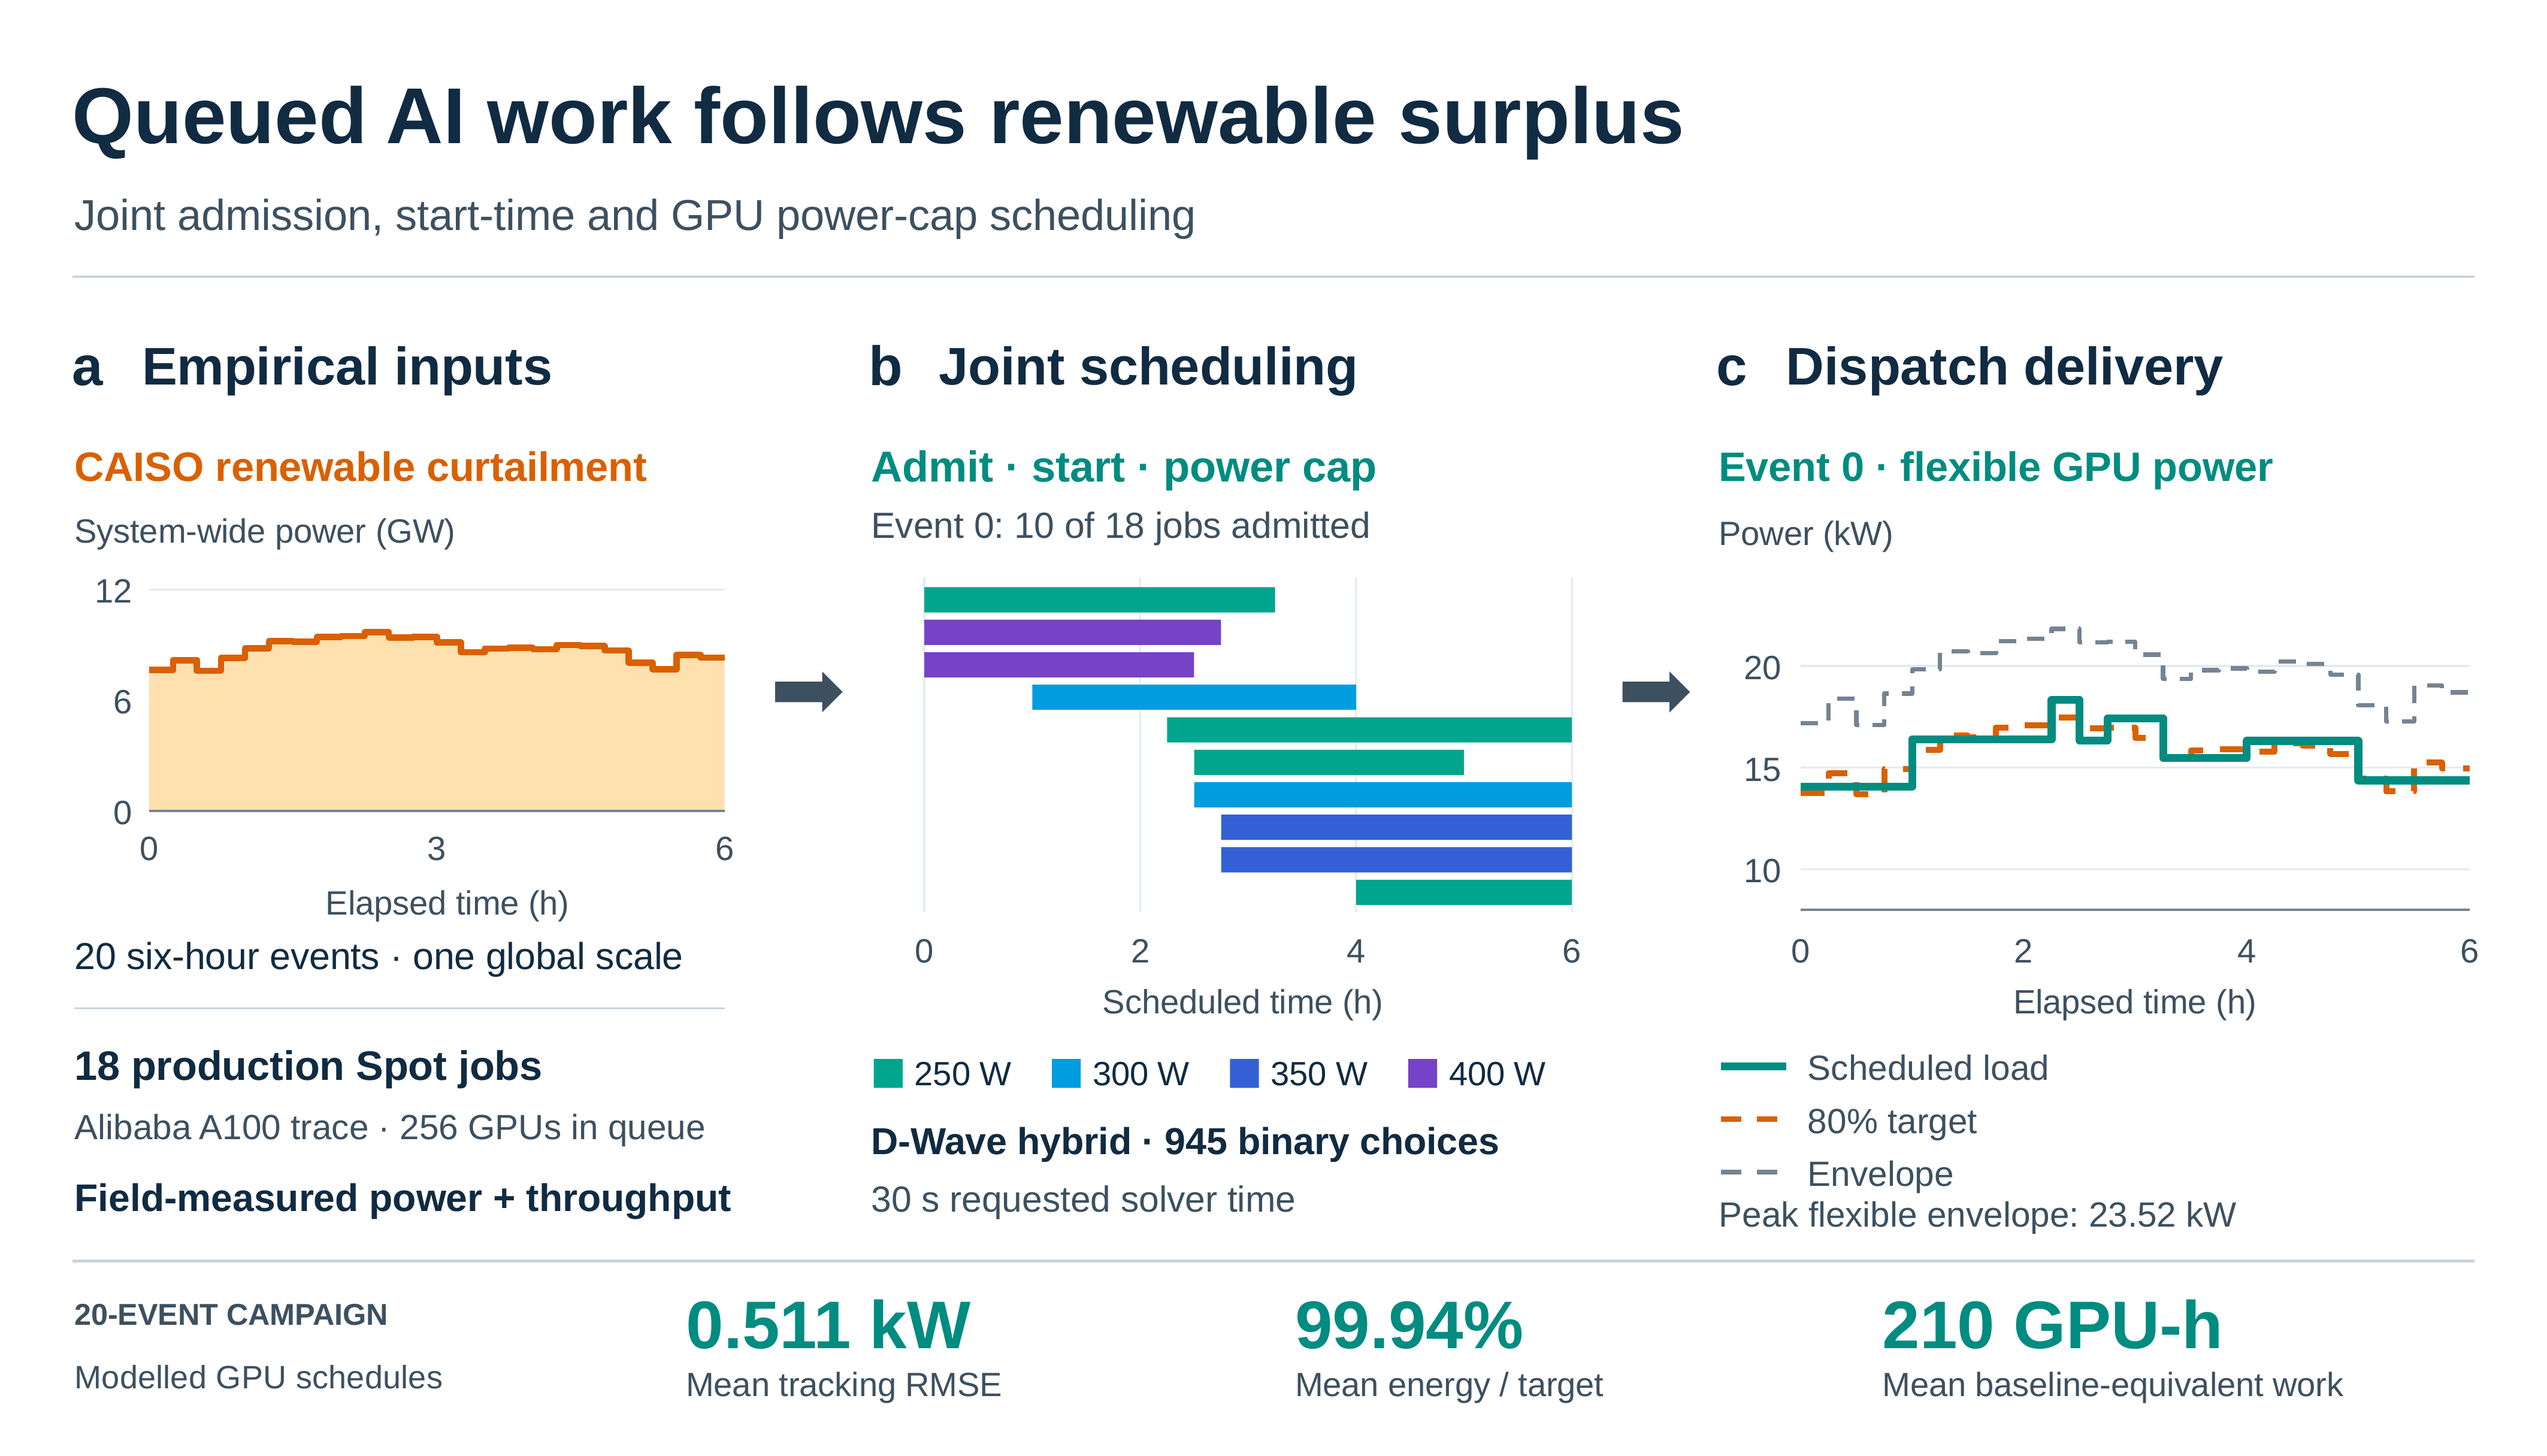

In [80]:
display(Image(filename=str(OUT/'fig01_overview.png'),width=950))

## Figure 2 empirical foundations

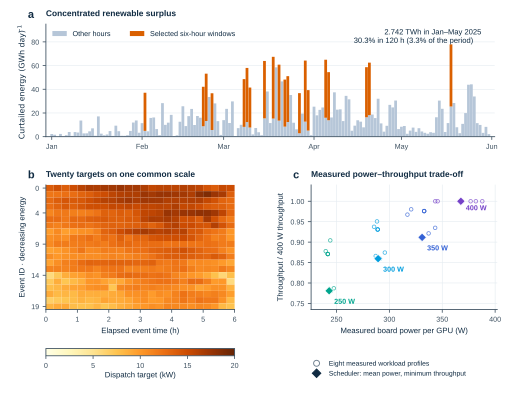

In [81]:
def fig02_empirical_foundations():
    fig=plt.figure(figsize=(180*MM,142*MM))
    a=fig.add_axes([.09,.66,.88,.28]); b=fig.add_axes([.09,.23,.37,.31]); c=fig.add_axes([.61,.23,.365,.31])
    d=pd.read_csv(DATA/'caiso_15min.csv',parse_dates=['timestamp'])
    d=d[(d.timestamp>='2025-01-01')&(d.timestamp<'2025-06-01')].copy()
    chosen_ts=pd.to_datetime(PROFILES.timestamp)
    d['selected_MWh']=np.where(d.timestamp.isin(chosen_ts), d.curtailment_energy_MWh, 0)
    day=d.set_index('timestamp')[['curtailment_energy_MWh','selected_MWh']].resample('D').sum()/1000
    a.bar(day.index,day.curtailment_energy_MWh-day.selected_MWh,width=.95,color='#B6C6D8',label='Other hours')
    a.bar(day.index,day.selected_MWh,bottom=day.curtailment_energy_MWh-day.selected_MWh,width=.95,color=ORANGE,label='Selected six-hour windows')
    a.set(ylabel='Curtailed energy (GWh day$^{-1}$)',ylim=(0,95),xlim=(pd.Timestamp('2024-12-30'),pd.Timestamp('2025-06-02')))
    a.set_yticks([0,20,40,60,80])
    a.xaxis.set_major_locator(mdates.MonthLocator()); a.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    a.legend(frameon=False,loc='upper left',ncol=2)
    a.text(.99,.96,'2.742 TWh in Jan–May 2025\n30.3% in 120 h (3.3% of the period)',ha='right',va='top',transform=a.transAxes,fontsize=7.6)
    panel(a,'a','Concentrated renewable surplus'); clean(a)
    source('fig02a_daily_curtailment_GWh',day.reset_index())
    z=PROFILES.pivot(index='event_id',columns='slot',values='dispatch_target_kW').sort_index().to_numpy()
    mesh=b.pcolormesh(EDGES,np.arange(21)-.5,z,cmap='YlOrBr',vmin=0,vmax=20,shading='flat',rasterized=False)
    b.set(xlim=(0,6),ylim=(19.5,-.5),xlabel='Elapsed event time (h)',ylabel='Event ID · decreasing energy')
    b.set_xticks(range(7));b.set_yticks([0,4,9,14,19])
    cb=fig.colorbar(mesh,cax=fig.add_axes([.09,.115,.37,.018]),orientation='horizontal',ticks=[0,5,10,15,20])
    cb.set_label('Dispatch target (kW)',labelpad=2)
    panel(b,'b','Twenty targets on one common scale')
    for cap, color in CAP.items():
        sw=SWEEP[SWEEP['GPU power cap']==cap]
        c.scatter(sw['power per GPU'],sw['normalized throughput'],s=13,facecolor='none',edgecolor=color,alpha=.72,lw=.8)
        r=CAL[CAL.power_cap_W==cap].iloc[0]
        c.scatter(r.power_per_gpu_W_mean,r.model_throughput_factor,s=37,marker='D',color=color,edgecolor='white',lw=.75,zorder=4)
        xy=(r.power_per_gpu_W_mean,r.model_throughput_factor)
        c.annotate(f'{cap} W',xy,xytext=(5,-9 if cap==400 else -13),textcoords='offset points',color=color,fontweight='bold',fontsize=7.2)
    c.set(xlabel='Measured board power per GPU (W)',ylabel='Throughput / 400 W throughput',xlim=(226,402),ylim=(.735,1.04))
    c.set_xticks([250,300,350,400]);c.set_yticks([.75,.8,.85,.9,.95,1])
    c.legend([Line2D([],[],marker='o',ls='',mfc='none',mec=GREY),Line2D([],[],marker='D',ls='',color=INK)],
             ['Eight measured workload profiles','Scheduler: mean power, minimum throughput'],loc='upper left',bbox_to_anchor=(-.04,-.36),frameon=False,fontsize=6.8)
    panel(c,'c','Measured power–throughput trade-off');clean(c,'both')
    source('fig02c_measurements_selected_caps',SWEEP[SWEEP['GPU power cap'].isin(CAP)])
    source('fig02c_scheduler_operating_points',CAL)
    return save(fig,'fig02_empirical_foundations')

path=fig02_empirical_foundations()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure 3 dispatch fidelity

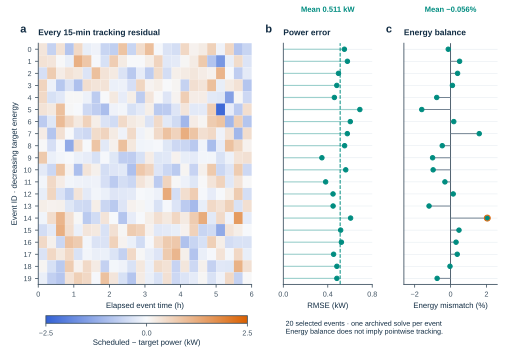

In [82]:
def fig03_dispatch_fidelity():
    fig=plt.figure(figsize=(180*MM,127*MM))
    gs=fig.add_gridspec(1,3,width_ratios=[2.4,1,1.05],left=.075,right=.975,bottom=.21,top=.88,wspace=.24)
    a=fig.add_subplot(gs[0]);b=fig.add_subplot(gs[1],sharey=a);c=fig.add_subplot(gs[2],sharey=a)
    residual=np.array([TRACES[i].dwave_gpu_load_kW-TRACES[i].dispatch_target_kW for i in range(20)])
    lim=np.ceil(np.max(np.abs(residual))*2)/2
    cmap=mcolors.LinearSegmentedColormap.from_list('error',[ '#3361D5','#F7F9FB',ORANGE])
    m=a.pcolormesh(EDGES,np.arange(21)-.5,residual,cmap=cmap,vmin=-lim,vmax=lim,shading='flat')
    a.set(xlim=(0,6),ylim=(19.5,-.5),xlabel='Elapsed event time (h)',ylabel='Event ID · decreasing target energy')
    a.set_xticks(range(7));a.set_yticks(range(20))
    for ax in (b,c):
        ax.tick_params(axis='y',left=False,labelleft=False)
        for yy in range(20):ax.axhline(yy,color=GRID,lw=.55,zorder=0)
    yy=np.arange(20)
    b.hlines(yy,0,METRICS.rmse_kW,color=TEAL,alpha=.35,lw=1.15)
    b.scatter(METRICS.rmse_kW,yy,color=TEAL,s=20,zorder=3)
    b.axvline(METRICS.rmse_kW.mean(),color=TEAL,ls='--',lw=1.0)
    b.set(xlim=(0,.8),xlabel='RMSE (kW)');b.set_xticks([0,.4,.8])
    c.axvline(0,color=MUTED,lw=.9)
    c.hlines(yy,0,METRICS.energy_mismatch_pct,color=GREY,lw=1)
    c.scatter(METRICS.energy_mismatch_pct,yy,color=TEAL,s=20,zorder=3)
    c.scatter(METRICS.loc[14,'energy_mismatch_pct'],14,s=36,facecolors='none',edgecolors=ORANGE,lw=1,zorder=4)
    c.set(xlim=(-2.6,2.6),xlabel='Energy mismatch (%)');c.set_xticks([-2,0,2])
    panel(a,'a','Every 15-min tracking residual');panel(b,'b','Power error');panel(c,'c','Energy balance')
    b.text(.5,1.13,'Mean 0.511 kW',transform=b.transAxes,ha='center',color=TEAL,fontsize=7.6,fontweight='bold')
    c.text(.5,1.13,'Mean −0.056%',transform=c.transAxes,ha='center',color=TEAL,fontsize=7.6,fontweight='bold')
    cax=fig.add_axes([.09,.102,.395,.021]);cb=fig.colorbar(m,cax=cax,orientation='horizontal',ticks=[-lim,0,lim])
    cb.set_label('Scheduled − target power (kW)',labelpad=2)
    fig.text(.56,.073,'20 selected events · one archived solve per event\nEnergy balance does not imply pointwise tracking.',fontsize=7.1,color=INK)
    df=pd.DataFrame(residual,columns=[f'slot_{i:02d}' for i in range(24)]);df.insert(0,'event_id',range(20));source('fig03a_residuals_kW',df)
    return save(fig,'fig03_dispatch_fidelity')

path=fig03_dispatch_fidelity()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure 4 useful compute

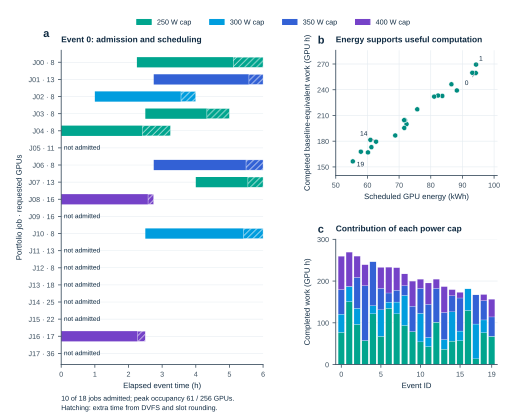

In [83]:
def fig04_useful_compute():
    fig=plt.figure(figsize=(180*MM,148*MM))
    gs=fig.add_gridspec(2,2,width_ratios=[1.25,1],left=.12,right=.975,bottom=.13,top=.88,wspace=.4,hspace=.51)
    a=fig.add_subplot(gs[:,0]);b=fig.add_subplot(gs[0,1]);c=fig.add_subplot(gs[1,1])
    ch=CHOSEN[0].set_index('portfolio_job_id')
    for j,job in JOBS.iterrows():
        jid=int(job.portfolio_job_id)
        a.axhline(j,color=GRID,lw=.5,zorder=0)
        if jid in ch.index:
            v=ch.loc[jid];start=v.start_slot*.25;end=v.end_slot_exclusive*.25
            baseline=v.baseline_duration_minutes/60
            a.barh(j,end-start,left=start,height=.6,color=CAP[int(v.power_cap_W)],edgecolor='none')
            a.barh(j,end-start-baseline,left=start+baseline,height=.6,
                   facecolor='none',edgecolor='white',hatch='////',linewidth=.4)
        else:
            a.text(.08,j,'not admitted',color=INK,fontsize=6.6,va='center')
    a.set_yticks(np.arange(18),[f'J{int(r.portfolio_job_id):02d} · {int(r.total_gpus)}' for _,r in JOBS.iterrows()])
    a.set(xlim=(0,6),ylim=(17.65,-.7),xlabel='Elapsed event time (h)',ylabel='Portfolio job · requested GPUs')
    a.set_xticks(range(7));panel(a,'a','Event 0: admission and scheduling')
    a.text(0,-.145,'10 of 18 jobs admitted; peak occupancy 61 / 256 GPUs.\nHatching: extra time from DVFS and slot rounding.',transform=a.transAxes,fontsize=7.0,color=INK,linespacing=1.5)
    b.scatter(METRICS.scheduled_kWh,METRICS.useful_gpu_h,s=26,color=TEAL,edgecolor='white',lw=.5,zorder=3)
    for e,offset in {0:(-11,-12),1:(3,4),14:(-16,6),19:(4,-5)}.items():
        r=METRICS.iloc[e];b.annotate(str(e),(r.scheduled_kWh,r.useful_gpu_h),xytext=offset,textcoords='offset points',fontsize=6.6,arrowprops={'arrowstyle':'-','color':GREY,'lw':.55})
    b.set(xlabel='Scheduled GPU energy (kWh)',ylabel='Completed baseline-equivalent work (GPU h)',xlim=(50,101),ylim=(140,286))
    b.set_xticks([50,60,70,80,90,100]);b.set_yticks([150,180,210,240,270])
    panel(b,'b','Energy supports useful computation');clean(b,'both')
    w=work_by_cap();z=w.pivot(index='event_id',columns='power_cap_W',values='useful_gpu_h')
    bottom=np.zeros(20)
    for cap in CAP:
        c.bar(range(20),z[cap],bottom=bottom,color=CAP[cap],width=.8,edgecolor='white',lw=.2);bottom+=z[cap].to_numpy()
    c.set(xlabel='Event ID',ylabel='Completed work (GPU h)',xlim=(-.7,19.7),ylim=(0,300))
    c.set_xticks([0,5,10,15,19]);c.set_yticks([0,100,200,300]);panel(c,'c','Contribution of each power cap');clean(c)
    cap_legend(fig,.97)
    source('fig04a_event00_schedule',CHOSEN[0]);source('fig04c_work_energy_by_cap',w)
    return save(fig,'fig04_useful_compute')

path=fig04_useful_compute()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure 5 solver benchmark

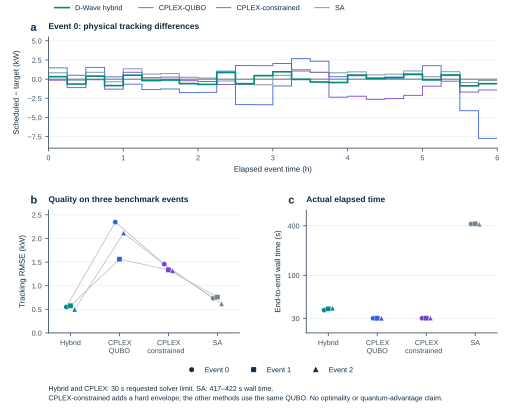

In [84]:
def fig05_solver_benchmark():
    fig=plt.figure(figsize=(180*MM,145*MM))
    gs=fig.add_gridspec(2,2,height_ratios=[.95,1.05],left=.095,right=.975,bottom=.19,top=.91,hspace=.53,wspace=.35)
    a=fig.add_subplot(gs[0,:]);b=fig.add_subplot(gs[1,0]);c=fig.add_subplot(gs[1,1])
    a.axhline(0,color=MUTED,lw=.85)
    for method in METHODS:
        if method=='D-Wave hybrid':d=TRACES[0];load=d.dwave_gpu_load_kW
        else:d=BASE_TRACES[(BASE_TRACES.event_id==0)&(BASE_TRACES.method==method)].sort_values('slot');load=d.gpu_load_kW
        step(a,load.to_numpy()-d.dispatch_target_kW.to_numpy(),color=MC[method],lw=1.65 if method=='D-Wave hybrid' else 1,alpha=1 if method=='D-Wave hybrid' else .85,label=method,zorder=5 if method=='D-Wave hybrid' else 2)
    a.set(xlim=(0,6),xlabel='Elapsed event time (h)',ylabel='Scheduled − target (kW)',ylim=(-9,5.5))
    a.set_xticks(range(7));a.legend(frameon=False,ncol=4,loc='lower left',bbox_to_anchor=(0,1.17),columnspacing=1.5)
    panel(a,'a','Event 0: physical tracking differences');clean(a)
    comp=comparison()
    for e in range(3):
        d=comp[comp.event_id==e].set_index('method').loc[METHODS]
        xs=np.arange(4)+(e-1)*.085
        b.plot(xs,d.tracking_RMSE_kW,color='#BAC5CE',lw=.85,zorder=1)
        for i,method in enumerate(METHODS):
            b.scatter(xs[i],d.loc[method,'tracking_RMSE_kW'],marker=MARKERS[e],s=26,color=MC[method],edgecolor='white',lw=.3,zorder=3)
            c.scatter(xs[i],d.loc[method,'wall_time_s'],marker=MARKERS[e],s=26,color=MC[method],edgecolor='white',lw=.3,zorder=3)
    labels=['Hybrid','CPLEX\nQUBO','CPLEX\nconstrained','SA']
    for ax in [b,c]:ax.set_xticks(range(4),labels);ax.set_xlim(-.45,3.45);clean(ax)
    b.set(ylabel='Tracking RMSE (kW)',ylim=(0,2.6));b.set_yticks([0,.5,1,1.5,2,2.5]);panel(b,'b','Quality on three benchmark events')
    c.set(ylabel='End-to-end wall time (s)',yscale='log',ylim=(20,620));c.set_yticks([30,100,400],['30','100','400'])
    c.yaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    panel(c,'c','Actual elapsed time')
    fig.legend([Line2D([],[],marker=m,color=INK,ls='',ms=4) for m in MARKERS],['Event 0','Event 1','Event 2'],
               frameon=False,ncol=3,loc='lower center',bbox_to_anchor=(.53,.075))
    fig.text(.095,.026,'Hybrid and CPLEX: 30 s requested solver limit. SA: 417–422 s wall time.\nCPLEX-constrained adds a hard envelope; the other methods use the same QUBO. No optimality or quantum-advantage claim.',fontsize=7.0,color=INK,linespacing=1.5)
    return save(fig,'fig05_solver_benchmark')

path=fig05_solver_benchmark()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure S1 event atlas

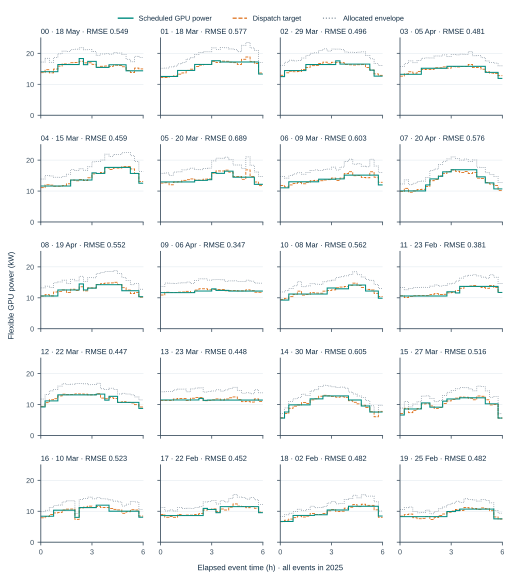

In [85]:
def figS01_event_atlas():
    fig,axes=plt.subplots(5,4,figsize=(180*MM,206*MM),sharex=True,sharey=True)
    fig.subplots_adjust(left=.08,right=.985,bottom=.07,top=.935,hspace=.38,wspace=.17)
    for e,ax in enumerate(axes.flat):
        d=TRACES[e]
        step(ax,d.allocated_curtailment_kW,color=GREY,lw=.75,ls=':')
        step(ax,d.dispatch_target_kW,color=ORANGE,lw=.8,ls='--')
        step(ax,d.dwave_gpu_load_kW,color=TEAL,lw=1.05)
        dt=pd.Timestamp(d.timestamp.iloc[0])
        ax.set_title(f'{e:02d} · {dt:%d %b} · RMSE {METRICS.rmse_kW[e]:.3f}',loc='left',fontsize=7.4,pad=4)
        ax.set(xlim=(0,6),ylim=(0,25));ax.set_xticks([0,3,6]);ax.set_yticks([0,10,20]);clean(ax)
    fig.legend([Line2D([],[],color=TEAL,lw=1.4),Line2D([],[],color=ORANGE,lw=1.1,ls='--'),Line2D([],[],color=GREY,lw=1.1,ls=':')],
               ['Scheduled GPU power','Dispatch target','Allocated envelope'],frameon=False,ncol=3,loc='upper center',bbox_to_anchor=(.52,.985))
    fig.text(.015,.5,'Flexible GPU power (kW)',rotation=90,va='center')
    fig.text(.53,.022,'Elapsed event time (h) · all events in 2025',ha='center')
    source('figS01_all_event_trajectories',pd.concat(TRACES.values(),ignore_index=True))
    return save(fig,'figS01_event_atlas')

path=figS01_event_atlas()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure S2 workload portfolio

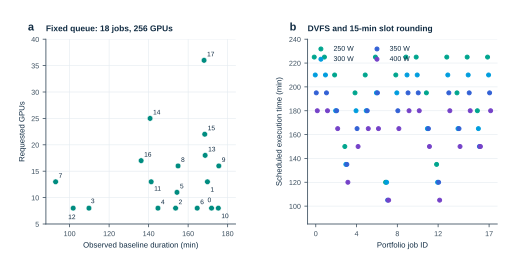

In [86]:
def figS02_workload_portfolio():
    fig,axes=plt.subplots(1,2,figsize=(180*MM,99*MM))
    fig.subplots_adjust(left=.09,right=.975,bottom=.2,top=.86,wspace=.38)
    a,b=axes
    a.scatter(JOBS.duration_minutes,JOBS.total_gpus,s=32,color=TEAL,edgecolor='white',lw=.5)
    offsets={0:(-4,6),1:(3,-10),10:(3,-10),11:(3,-9),12:(-5,-11),3:(2,5)}
    for _,r in JOBS.iterrows():
        a.annotate(str(int(r.portfolio_job_id)),(r.duration_minutes,r.total_gpus),xytext=offsets.get(int(r.portfolio_job_id),(3,4)),textcoords='offset points',fontsize=6.6)
    a.set(xlabel='Observed baseline duration (min)',ylabel='Requested GPUs',xlim=(88,184),ylim=(5,40))
    panel(a,'a','Fixed queue: 18 jobs, 256 GPUs');clean(a,'both')
    candidates=pd.read_csv(DATA/'candidate_variable_table.csv')
    rows=candidates.drop_duplicates(['portfolio_job_id','power_cap_W']).sort_values(['portfolio_job_id','power_cap_W'])
    for cap,color in CAP.items():
        d=rows[rows.power_cap_W==cap]
        b.scatter(d.portfolio_job_id+(cap-325)/500,d.duration_slots*15,color=color,s=16,label=f'{cap} W')
    b.set(xlabel='Portfolio job ID',ylabel='Scheduled execution time (min)',xlim=(-.8,17.8),ylim=(85,240))
    b.set_xticks([0,4,8,12,17]);b.legend(frameon=False,ncol=2,loc='upper left',fontsize=7.0)
    panel(b,'b','DVFS and 15-min slot rounding');clean(b)
    source('figS02a_portfolio',JOBS);source('figS02b_job_cap_durations',rows)
    return save(fig,'figS02_workload_portfolio')

path=figS02_workload_portfolio()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure S3 field calibration

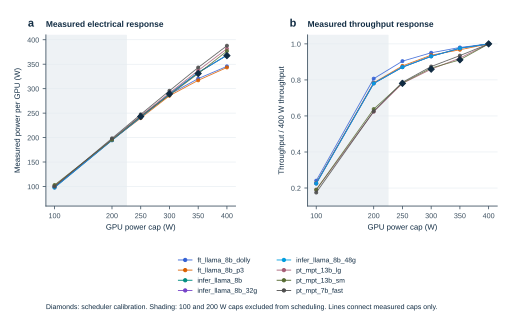

In [87]:
def figS03_field_calibration():
    fig,axes=plt.subplots(1,2,figsize=(180*MM,112*MM))
    fig.subplots_adjust(left=.09,right=.975,bottom=.35,top=.89,wspace=.38)
    a,b=axes
    palette=['#3361D5','#DA6000','#008C80','#7542C8','#009DDE','#A65D75','#566B32','#4D4D4D']
    handles=[];labels=[]
    for i,(name,d) in enumerate(SWEEP.groupby('Workload',sort=True)):
        d=d.sort_values('GPU power cap')
        for ax,y in [(a,'power per GPU'),(b,'normalized throughput')]:
            ax.plot(d['GPU power cap'],d[y],color=palette[i],marker='o',ms=3.0,lw=.85,alpha=.85)
        handles.append(Line2D([],[],color=palette[i],marker='o',ms=3.3,lw=.9));labels.append(name)
    a.plot(CAL.power_cap_W,CAL.power_per_gpu_W_mean,'D',color=INK,ms=4.3,zorder=5)
    b.plot(CAL.power_cap_W,CAL.model_throughput_factor,'D',color=INK,ms=4.3,zorder=5)
    for ax in axes:
        ax.axvspan(85,225,color='#EEF2F5',zorder=0)
        ax.set(xlabel='GPU power cap (W)',xlim=(85,415));ax.set_xticks([100,200,250,300,350,400]);clean(ax)
    a.set(ylabel='Measured power per GPU (W)',ylim=(60,410));b.set(ylabel='Throughput / 400 W throughput',ylim=(.1,1.05))
    panel(a,'a','Measured electrical response');panel(b,'b','Measured throughput response')
    fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(.53,.052),frameon=False,ncol=2,fontsize=6.8,columnspacing=2)
    fig.text(.09,.025,'Diamonds: scheduler calibration. Shading: 100 and 200 W caps excluded from scheduling. Lines connect measured caps only.',fontsize=7.0,color=INK)
    source('figS03_full_field_sweep',SWEEP)
    return save(fig,'figS03_field_calibration')

path=figS03_field_calibration()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure S4 energy compute audit

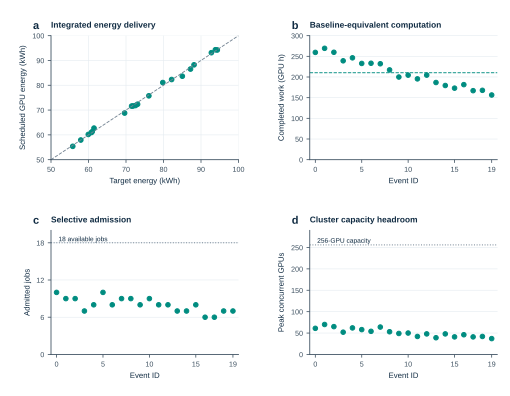

In [88]:
def figS04_energy_compute_audit():
    fig,axes=plt.subplots(2,2,figsize=(180*MM,140*MM))
    fig.subplots_adjust(left=.1,right=.975,bottom=.105,top=.91,hspace=.57,wspace=.38)
    a,b,c,d=axes.flat
    a.plot([50,100],[50,100],ls='--',color=GREY,lw=.9)
    a.scatter(METRICS.target_kWh,METRICS.scheduled_kWh,color=TEAL,s=22)
    a.set(xlabel='Target energy (kWh)',ylabel='Scheduled GPU energy (kWh)',xlim=(50,100),ylim=(50,100));panel(a,'a','Integrated energy delivery');clean(a,'both')
    b.scatter(range(20),METRICS.useful_gpu_h,color=TEAL,s=21)
    b.axhline(METRICS.useful_gpu_h.mean(),ls='--',color=TEAL,lw=.9)
    b.set(xlabel='Event ID',ylabel='Completed work (GPU h)',ylim=(0,300));panel(b,'b','Baseline-equivalent computation')
    c.scatter(range(20),METRICS.jobs,color=TEAL,s=21)
    c.axhline(18,color=GREY,ls=':',lw=1.0);c.text(.2,18.25,'18 available jobs',color=INK,fontsize=6.6)
    c.set(xlabel='Event ID',ylabel='Admitted jobs',ylim=(0,20));panel(c,'c','Selective admission')
    c.set_yticks([0,6,12,18])
    d.scatter(range(20),METRICS.peak_gpus,color=TEAL,s=21)
    d.axhline(256,color=GREY,ls=':',lw=1.0);d.text(.2,261,'256-GPU capacity',color=INK,fontsize=6.6)
    d.set(xlabel='Event ID',ylabel='Peak concurrent GPUs',ylim=(0,290));panel(d,'d','Cluster capacity headroom')
    for ax in (b,c,d):ax.set_xlim(-.6,19.6);ax.set_xticks([0,5,10,15,19]);clean(ax)
    return save(fig,'figS04_energy_compute_audit')

path=figS04_energy_compute_audit()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure S5 benchmark trajectories

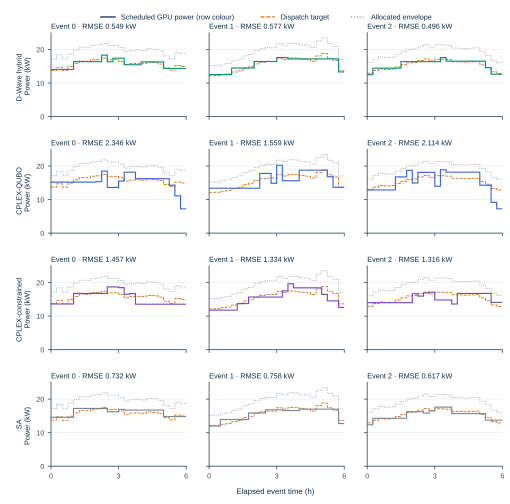

In [89]:
def figS05_benchmark_trajectories():
    fig,axes=plt.subplots(4,3,figsize=(180*MM,178*MM),sharex=True,sharey=True)
    fig.subplots_adjust(left=.1,right=.985,bottom=.075,top=.935,hspace=.39,wspace=.17)
    for row,method in enumerate(METHODS):
        for e in range(3):
            ax=axes[row,e]
            if method=='D-Wave hybrid':d=TRACES[e];load=d.dwave_gpu_load_kW
            else:d=BASE_TRACES[(BASE_TRACES.event_id==e)&(BASE_TRACES.method==method)].sort_values('slot');load=d.gpu_load_kW
            step(ax,d.allocated_curtailment_kW,color=GREY,lw=.7,ls=':')
            step(ax,d.dispatch_target_kW,color=ORANGE,lw=.8,ls='--')
            step(ax,load,color=MC[method],lw=1.1)
            r=comparison().query('event_id == @e and method == @method').iloc[0]
            ax.set_title(f'Event {e} · RMSE {r.tracking_RMSE_kW:.3f} kW',loc='left',fontsize=7.3,pad=4)
            ax.set(xlim=(0,6),ylim=(0,25));ax.set_xticks([0,3,6]);ax.set_yticks([0,10,20]);clean(ax)
            if e==0:ax.set_ylabel(method+'\nPower (kW)',fontsize=7.3)
    fig.legend([Line2D([],[],color=INK,lw=1.3),Line2D([],[],color=ORANGE,lw=1.1,ls='--'),Line2D([],[],color=GREY,lw=1.1,ls=':')],
        ['Scheduled GPU power (row colour)','Dispatch target','Allocated envelope'],frameon=False,ncol=3,loc='upper center',bbox_to_anchor=(.53,.985))
    fig.text(.54,.02,'Elapsed event time (h)',ha='center')
    return save(fig,'figS05_benchmark_trajectories')

path=figS05_benchmark_trajectories()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure S6 objective and resources

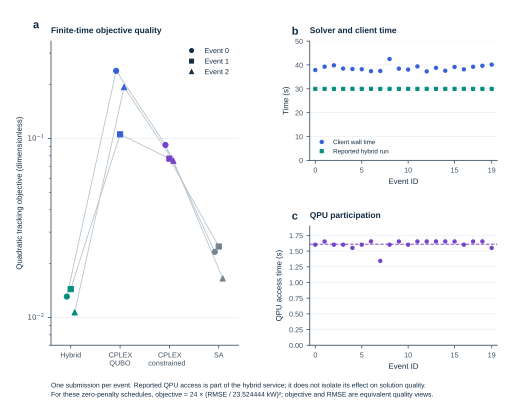

In [90]:
def figS06_objective_and_resources():
    fig=plt.figure(figsize=(180*MM,145*MM))
    gs=fig.add_gridspec(2,2,left=.1,right=.975,bottom=.16,top=.9,wspace=.38,hspace=.55)
    a=fig.add_subplot(gs[:,0]);b=fig.add_subplot(gs[0,1]);c=fig.add_subplot(gs[1,1])
    comp=comparison()
    for e in range(3):
        d=comp[comp.event_id==e].set_index('method').loc[METHODS]
        xx=np.arange(4)+(e-1)*.08
        a.plot(xx,d.tracking_objective,color='#BAC5CE',lw=.9)
        for i,method in enumerate(METHODS):a.scatter(xx[i],d.loc[method,'tracking_objective'],color=MC[method],marker=MARKERS[e],s=27,zorder=4)
    a.set_xticks(range(4),['Hybrid','CPLEX\nQUBO','CPLEX\nconstrained','SA'])
    a.set(xlim=(-.4,3.4),yscale='log',ylim=(.007,.35),ylabel='Quadratic tracking objective (dimensionless)')
    a.legend([Line2D([],[],marker=m,color=INK,ls='',ms=4) for m in MARKERS],['Event 0','Event 1','Event 2'],frameon=False,loc='upper right')
    panel(a,'a','Finite-time objective quality');clean(a)
    b.plot(range(20),SUMMARY.client_wall_time_s,'o',color=MC['CPLEX-QUBO'],ms=3.4,label='Client wall time')
    b.plot(range(20),SUMMARY.run_time_s,'s',color=TEAL,ms=3.1,label='Reported hybrid run')
    b.set(xlabel='Event ID',ylabel='Time (s)',ylim=(0,50));b.legend(frameon=False,loc='lower left',fontsize=6.3)
    panel(b,'b','Solver and client time')
    c.plot(range(20),SUMMARY.qpu_access_time_s,'o',color=MC['CPLEX-constrained'],ms=3.4)
    c.axhline(SUMMARY.qpu_access_time_s.mean(),color=MC['CPLEX-constrained'],lw=.95,ls='--')
    c.set(xlabel='Event ID',ylabel='QPU access time (s)',ylim=(0,1.9));panel(c,'c','QPU participation')
    for ax in (b,c):ax.set_xlim(-.6,19.6);ax.set_xticks([0,5,10,15,19]);clean(ax)
    fig.text(.1,.035,'One submission per event. Reported QPU access is part of the hybrid service; it does not isolate its effect on solution quality.\nFor these zero-penalty schedules, objective = 24 × (RMSE / 23.524444 kW)²; objective and RMSE are equivalent quality views.',fontsize=6.8,color=INK,linespacing=1.5)
    return save(fig,'figS06_objective_and_resources')

path=figS06_objective_and_resources()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure S7 mode composition

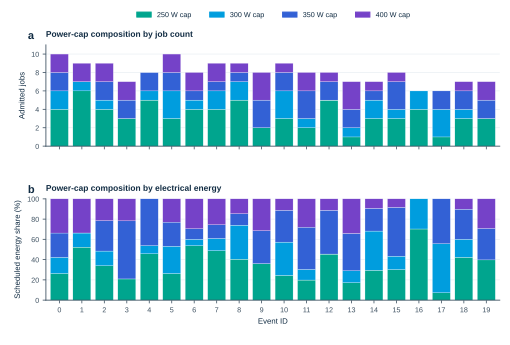

In [91]:
def figS07_mode_composition():
    fig,axes=plt.subplots(2,1,figsize=(180*MM,122*MM),sharex=True)
    fig.subplots_adjust(left=.09,right=.98,bottom=.13,top=.87,hspace=.52)
    w=work_by_cap()
    for ax,metric,label,letter in [(axes[0],'jobs','Admitted jobs','a'),(axes[1],'energy_kWh','Scheduled energy share (%)','b')]:
        z=w.pivot(index='event_id',columns='power_cap_W',values=metric)
        if metric=='energy_kWh':z=z.div(z.sum(axis=1),axis=0)*100
        bottom=np.zeros(20)
        for cap in CAP:
            ax.bar(range(20),z[cap],bottom=bottom,width=.8,color=CAP[cap],edgecolor='white',lw=.25);bottom+=z[cap].to_numpy()
        ax.set(ylabel=label,xlim=(-.6,19.6),ylim=(0,11 if metric=='jobs' else 100));clean(ax)
        panel(ax,letter,'Power-cap composition by job count' if metric=='jobs' else 'Power-cap composition by electrical energy')
    axes[1].set_xticks(range(20));axes[1].set_xlabel('Event ID');cap_legend(fig,.985)
    return save(fig,'figS07_mode_composition')

path=figS07_mode_composition()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Figure S8 envelope audit

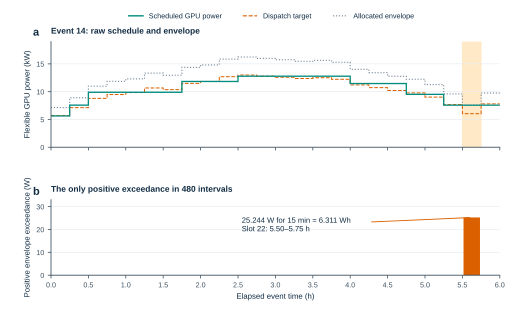

In [92]:
def figS08_envelope_audit():
    fig,axes=plt.subplots(2,1,figsize=(180*MM,113*MM),sharex=True,gridspec_kw={'height_ratios':[1.4,1]})
    fig.subplots_adjust(left=.1,right=.98,bottom=.14,top=.87,hspace=.58)
    a,b=axes;d=TRACES[14]
    step(a,d.allocated_curtailment_kW,color=GREY,lw=1.1,ls=':')
    step(a,d.dispatch_target_kW,color=ORANGE,lw=1,ls='--')
    step(a,d.dwave_gpu_load_kW,color=TEAL,lw=1.3)
    a.set(ylabel='Flexible GPU power (kW)',ylim=(0,19));panel(a,'a','Event 14: raw schedule and envelope');clean(a)
    x=5.625
    a.axvspan(5.5,5.75,color=PALE,alpha=.7,zorder=0)
    excess=np.maximum(d.dwave_gpu_load_kW-d.allocated_curtailment_kW,0)*1000
    b.bar(T+.125,excess,width=.22,color=ORANGE)
    b.set(xlim=(0,6),ylim=(0,33),xlabel='Elapsed event time (h)',ylabel='Positive envelope exceedance (W)')
    b.set_xticks(np.arange(0,6.1,.5));b.set_yticks([0,10,20,30]);panel(b,'b','The only positive exceedance in 480 intervals');clean(b)
    b.annotate('25.244 W for 15 min = 6.311 Wh\nSlot 22: 5.50–5.75 h',xy=(x,excess.max()),xytext=(2.55,22),arrowprops={'arrowstyle':'-','color':ORANGE,'lw':.9},fontsize=7.6,color=INK,va='center')
    fig.legend([Line2D([],[],color=TEAL,lw=1.4),Line2D([],[],color=ORANGE,lw=1.1,ls='--'),Line2D([],[],color=GREY,lw=1.1,ls=':')],
        ['Scheduled GPU power','Dispatch target','Allocated envelope'],frameon=False,ncol=3,loc='upper center',bbox_to_anchor=(.54,.98))
    audit=d.copy();audit['positive_exceedance_W']=excess;source('figS08_event14_audit',audit)
    return save(fig,'figS08_envelope_audit')

path=figS08_envelope_audit()
display(SVG(filename=str(path.with_suffix('.svg'))))

## Verification and input fingerprints
A single archived solve exists per event. Across-event spread is not repeated-solver uncertainty. The field measurements calibrate a scheduling model; the plotted Alibaba job completions were not executed in a live trial.

In [93]:
manifest={str(p.relative_to(ROOT)):hashlib.sha256(p.read_bytes()).hexdigest() for p in sorted(DATA.rglob('*')) if p.is_file()}
(ROOT/'verification/input_sha256.json').write_text(json.dumps(manifest,indent=2))
validate()

{'rmse_kW_max_abs_error': 4.440892098500626e-16,
 'target_kWh_max_abs_error': 0.0,
 'scheduled_kWh_max_abs_error': 1.4210854715202004e-14,
 'useful_gpu_h_max_abs_error': 2.842170943040401e-14,
 'jobs_max_abs_error': 0.0,
 'peak_gpus_max_abs_error': 0.0,
 'events': 20,
 'intervals': 480,
 'admitted_job_instances': 160,
 'unique_jobs': 18,
 'all_loads_reconstructed': True,
 'all_baseline_objective_identities_verified': True,
 'source_data_only': True,
 'no_new_solver_calls': True}